# 06. Dielectric Model — k 데이터 수집 및 조인

Materials Project API에서 유전율(dielectric constant) 데이터를 수집하고,
기존 high-k 후보 소재(featurized_highk.csv)와 조인하여 모델 학습 데이터셋을 구축합니다.

**목표**: DRAM high-k 유전체 후보 소재의 유전율 예측 모델 개발

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from dotenv import load_dotenv
from mp_api.client import MPRester

load_dotenv('../.env')
API_KEY = os.getenv('MP_API_KEY')

with MPRester(API_KEY) as mpr:
    docs = mpr.materials.dielectric.search(
        fields=["material_id", "e_total", "e_electronic", "e_ionic"]
    )

# Handle both dict and object responses from mp-api
def get_attr(d, key):
    if isinstance(d, dict):
        return d.get(key)
    return getattr(d, key, None)

dielectric_df = pd.DataFrame([{
    'material_id': get_attr(d, 'material_id'),
    'e_total': float(get_attr(d, 'e_total')),
    'e_electronic': float(get_attr(d, 'e_electronic')) if get_attr(d, 'e_electronic') is not None else None,
    'e_ionic': float(get_attr(d, 'e_ionic')) if get_attr(d, 'e_ionic') is not None else None
} for d in docs if get_attr(d, 'e_total') is not None])

print(f"MP dielectric 데이터: {len(dielectric_df)}개")
print(f"e_total 범위: {dielectric_df['e_total'].min():.1f} ~ {dielectric_df['e_total'].max():.1f}")
print(f"e_electronic null: {dielectric_df['e_electronic'].isna().sum()}개")
print(f"e_ionic null: {dielectric_df['e_ionic'].isna().sum()}개")
print(f"중앙값: {dielectric_df['e_total'].median():.1f}")
dielectric_df.head()

MP dielectric 데이터: 7332개
e_total 범위: 1.2 ~ 126575.3
중앙값: 11.7


,material_id,e_total,e_electronic,e_ionic
0,mp-14,10.555159,9.692769,0.862390
1,mp-19,58.937522,43.624508,15.313013
2,mp-32,25.853525,25.853525,0.000000
3,mp-66,5.829714,5.829714,0.000000
4,mp-77,2.953744,2.832110,0.121634


In [2]:
featurized = pd.read_csv('../data/featurized_highk.csv')
print(f"featurized_highk: {len(featurized)}개")

merged = featurized.merge(dielectric_df, on='material_id', how='inner')
print(f"조인 후 (k 보유 후보): {len(merged)}개")
print(f"전체 {len(featurized)}개 중 {len(merged)/len(featurized)*100:.1f}% 가 k 데이터 보유")
# 84% 손실은 정상: MP의 DFT 유전상수 계산은 전체 소재의 ~5%에만 수행됨.
# 계산 비용이 크기 때문. composition-only ML 예측이 필요한 이유.

# e_total 분포 확인
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(merged['e_total'], bins=50, color='steelblue', edgecolor='white')
plt.xlabel('e_total (dielectric constant)')
plt.ylabel('Count')
plt.title('Raw e_total Distribution')

plt.subplot(1, 2, 2)
plt.hist(np.log10(merged['e_total'].clip(lower=0.1)), bins=50, color='darkorange', edgecolor='white')
plt.xlabel('log10(e_total)')
plt.ylabel('Count')
plt.title('log10 Distribution')
plt.tight_layout()
plt.savefig('../data/dielectric_distribution.png', dpi=150)
plt.show()


# 이상치(e_total > 100)는 다음 셀에서 필터링: BaTiO₃ 계열 강유전체 제외
outliers = merged[merged['e_total'] > 100]
print(f"이상치 (e_total > 100, 다음 셀에서 필터링 예정): {len(outliers)}개 — {outliers['formula'].head(3).values}")

merged.to_csv('../data/highk_with_dielectric.csv', index=False)
print("저장 완료: data/highk_with_dielectric.csv")

featurized_highk: 3914개
조인 후 (k 보유 후보): 624개
전체 3914개 중 15.9% 가 k 데이터 보유
Plot saved: data/dielectric_distribution.png
저장 완료: data/highk_with_dielectric.csv


In [3]:
# Cell 3
df = pd.read_csv('../data/highk_with_dielectric.csv')

# DRAM 관련 범위: 1 < e_total < 100 (강유전체 제외)
df_filtered = df[(df['e_total'] > 1) & (df['e_total'] < 100)].copy()
print(f"원본: {len(df)}개 → 필터 후 (1 < e_total < 100): {len(df_filtered)}개")

feature_cols = [c for c in df_filtered.columns
                if c not in ['material_id', 'formula', 'band_gap',
                             'e_total', 'e_electronic', 'e_ionic']]
print(f"사용 feature: {len(feature_cols)}개")

X = df_filtered[feature_cols]
y = df_filtered['e_total']

print(f"
e_total 통계:")
print(y.describe().round(2))

원본: 624개 → 필터 후 (1 < e_total < 100): 619개
사용 feature: 132개

e_total 통계:
count    619.00
mean      12.62
std        9.26
min        2.33
25%        7.02
50%        9.55
75%       14.19
max       63.84
Name: e_total, dtype: float64


In [4]:
# Cell 4
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train)}  Test: {len(X_test)}")

model_k = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
model_k.fit(X_train, y_train)

y_pred = model_k.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"
MAE : {mae:.3f}")
print(f"R²  : {r2:.3f}")
print("(목표: R² > 0.6 — composition-only로 0.6+ 달성 시 충분)")

Train: 495  Test: 124

MAE : 3.434
R²  : 0.714
(목표: R² > 0.6 — composition-only로 0.6+ 달성 시 충분)


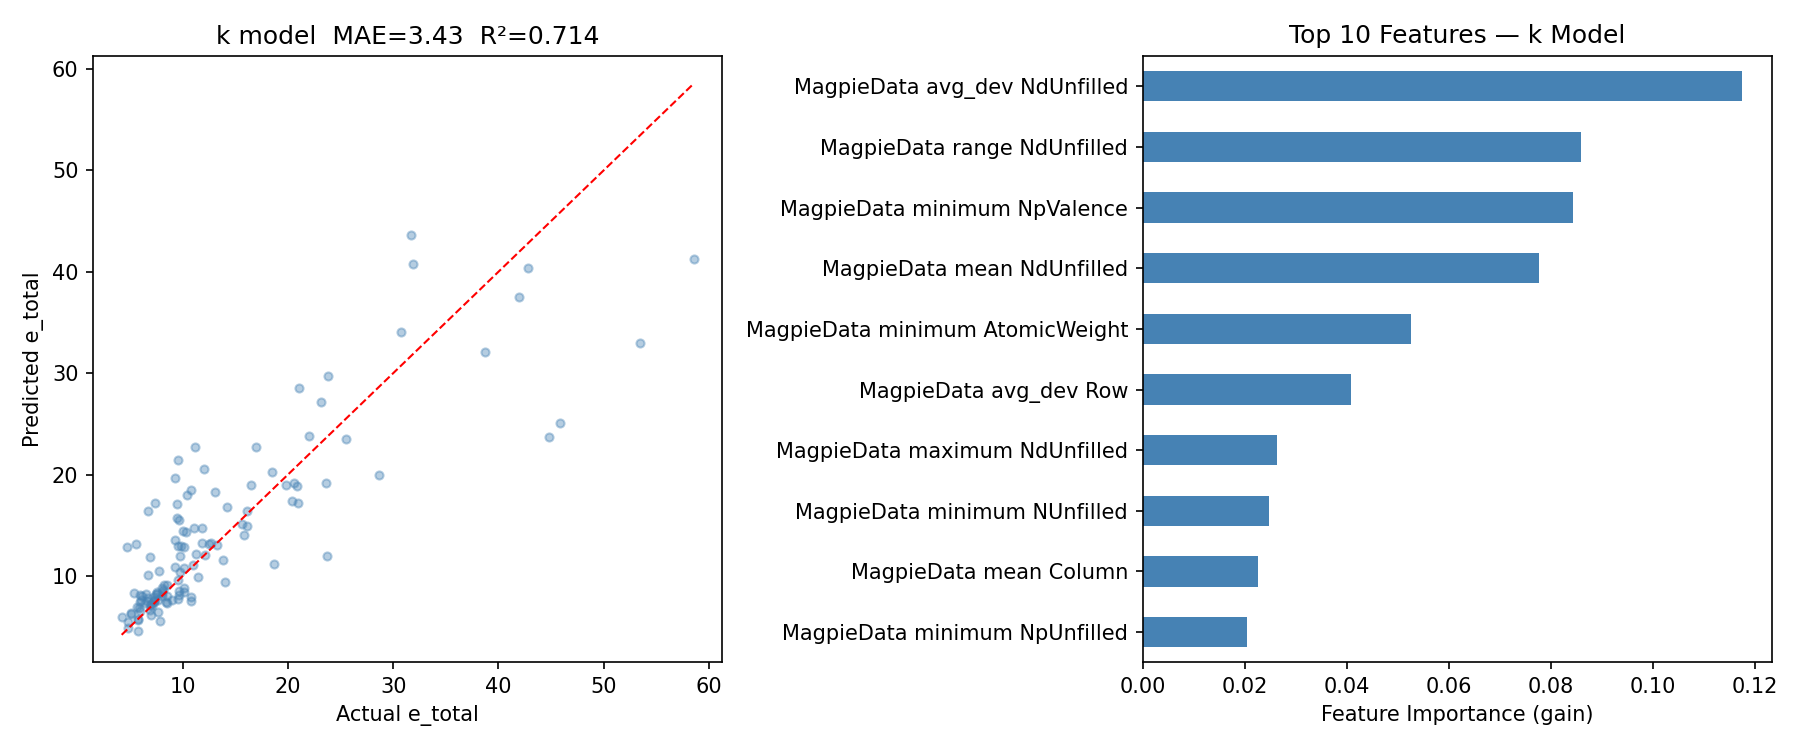

모델 저장 완료: data/xgb_dielectric_model.json


In [5]:
# Cell 5
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, y_pred, alpha=0.4, s=15, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_xlabel('Actual e_total')
axes[0].set_ylabel('Predicted e_total')
axes[0].set_title(f'k model  MAE={mae:.2f}  R²={r2:.3f}')

# Feature importance Top 10 미리보기
importance = pd.Series(model_k.feature_importances_, index=feature_cols)
top10 = importance.sort_values(ascending=False).head(10)
top10[::-1].plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_xlabel('Feature Importance (gain)')
axes[1].set_title('Top 10 Features — k Model')

plt.tight_layout()
plt.savefig('../data/dielectric_model_eval.png', dpi=150)
plt.show()

model_k.save_model('../data/xgb_dielectric_model.json')
print("모델 저장 완료: data/xgb_dielectric_model.json")